This problem focusses on the collinearity problem.

**Part (a)**\
Perform the following commands in Python:

```ruby
rng = np.random.default_rng(10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)
```

The last line corresponds to creating a linear model in which `y` is a function of `x1` and `x2`. Write out the form of the linear model. What are the regression coefficients?

The linear model is

$$Y = 2 + 2X_1 + 0.3X_2 + \epsilon$$

with regression coefficients $2$ and $0.3$ for $X_1$ and $X_2$ respectively.

**Part (b)**\
What is the correlation between `x1` and `x2`? Create a scatterplot displaying the relationship between the variables.

Correlation = 0.7723244976913541


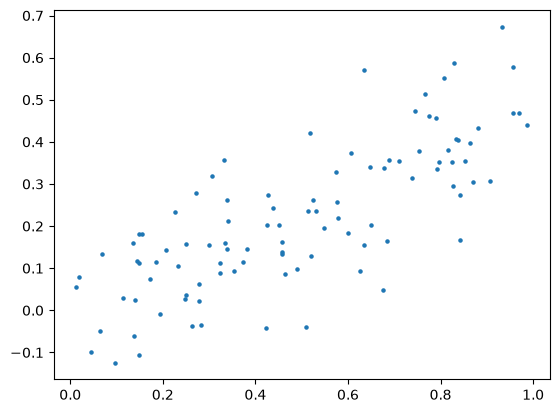

In [3]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

print(f'Correlation = {np.corrcoef(x1, x2)[1][0]}')

plt.scatter(x1, x2, s=5);

**Part (c)**\
Using this data, fit a least squares regression to predict `y` using `x1` and `x2`. Describe the results obtained. What are the estimates of $\beta_0$, $\beta_1$, and $\beta_2$? How do these relate to the true $\beta_0$, $\beta_1$, and $\beta_2$? Can you reject the null hypotheses $H_0: \beta_1 = 0$ and $H_0: \beta_2 = 0$?

In [4]:
import statsmodels.api as sm
import pandas as pd

X = pd.DataFrame({'x1':x1, 'x2':x2})
X['intercept'] = 1

linear_model = sm.OLS(y, X).fit()
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     19.89
Date:                Fri, 31 Jul 2026   Prob (F-statistic):           5.76e-08
Time:                        21:48:22   Log-Likelihood:                -130.62
No. Observations:                 100   AIC:                             267.2
Df Residuals:                      97   BIC:                             275.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             1.6154      0.527      3.065      0.0

The estimates for $\beta_0$, $\beta_1$, and $\beta_2$ are $1.9579$, $1.6154$, and $0.9428$ respectively.\
The estimate for $\beta_0$ is very close to the true value of $2$, but the estimates for $\beta_1$ and $\beta_2$ are quite far off from the true values of $2$ and $0.3$ respecively.\
At a $5\%$ significance level, we can reject $H_0: \beta_1=0$, but not $H_0: \beta_2 = 0$.

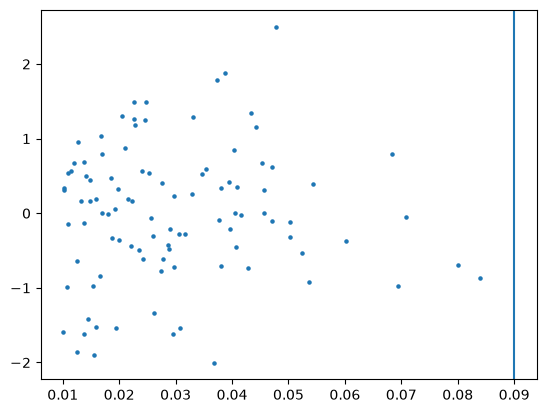

In [23]:
residuals = linear_model.resid
leverage = linear_model.get_influence().hat_matrix_diag

average_leverage = np.mean(leverage)

plt.scatter(leverage, residuals, s=5);
plt.axvline(3*average_leverage);

**Part (d)**\
Now fit a least square regression to predict `y` using only `x1`. Comment on your results. Can you reject the null hypothesis $H_0: \beta_1 = 0$?

In [24]:
X1 = pd.DataFrame({'x1':x1})
X1['intercept'] = 1

linear_model_1 = sm.OLS(y, X1).fit()
print(linear_model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     4.149
Date:                Fri, 31 Jul 2026   Prob (F-statistic):             0.0442
Time:                        21:51:03   Log-Likelihood:                -175.40
No. Observations:                 107   AIC:                             354.8
Df Residuals:                     105   BIC:                             360.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.8863      0.435      2.037      0.0

Both the estimates of $\beta_0$ and $\beta_1$ are close to the true values.\
We can reject the null hypothesis $H_0: \beta_1 = 0$ at a $5\%$ significance level.

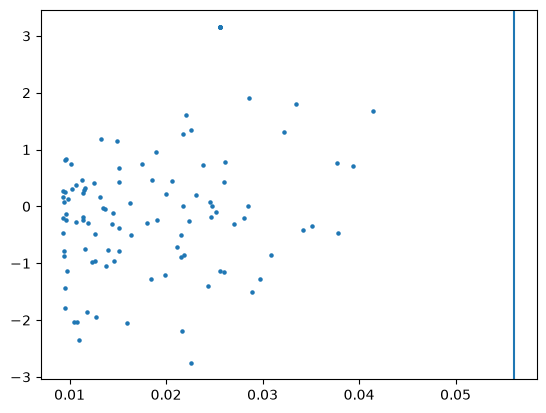

In [25]:
residuals_1 = linear_model_1.resid
leverage_1 = linear_model_1.get_influence().hat_matrix_diag

average_leverage_1 = np.mean(leverage_1)

plt.scatter(leverage_1, residuals_1, s=5);
plt.axvline(3*average_leverage_1);

**Part (e)**\
Now fit a least squares regression to predict `y` using only `x2`. Comment on your results. Can you reject the null hypothesis $H_0: \beta_2 = 0$?

In [26]:
X2 = pd.DataFrame({'x2':x2})
X2['intercept'] = 1

linear_model_2 = sm.OLS(y, X2).fit()
print(linear_model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     87.31
Date:                Fri, 31 Jul 2026   Prob (F-statistic):           1.81e-15
Time:                        21:51:03   Log-Likelihood:                -145.10
No. Observations:                 107   AIC:                             294.2
Df Residuals:                     105   BIC:                             299.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x2             3.9028      0.418      9.344      0.0

The estimate for $\beta_0$ is somewhat far from the true value, and the estimate for $\beta_2$ is very far from the true value.\
However, at a $5\%$ significance level, we can reject $H_0: \beta_2 = 0$.

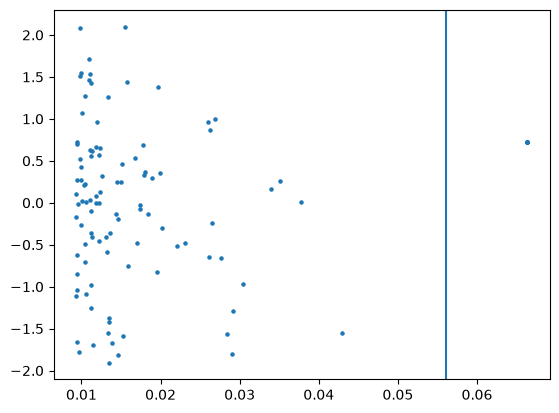

In [27]:
residuals_2 = linear_model_2.resid
leverage_2 = linear_model_2.get_influence().hat_matrix_diag

average_leverage_2 = np.mean(leverage_2)

plt.scatter(leverage_2, residuals_2, s=5);
plt.axvline(3*average_leverage_2);

**Part (f)**\
Do the results obtained in parts (c) to (e) contradict each other? Explain your answer.

**Part (g)**\
Suppose we obtain one additional observation, which was unfortunately mismeasured. We use the function `np.concatenate()` to add this additional observation to each of `x1`, `x2`, and `y`:

```ruby
x1 = np.concatenate([x1, [0.1]])
x2 = np.concatenate([x2, [0.8]])
y = np.concatenate([y, [6]])
```

Re-fit the linear models from parts (c) to (e) using this new data. What effect does this new observation have on each of the models? In each model, is this observation an outlier? A high-leverage point? Both? Explain your answers.

In [28]:
x1 = np.concatenate([x1, [0.1]])
x2 = np.concatenate([x2, [0.8]])
y = np.concatenate([y, [6]])

X = pd.DataFrame({'x1':x1, 'x2':x2})
X['intercept'] = 1

refit_model = sm.OLS(y, X).fit()
print(refit_model.summary())

X1 = pd.DataFrame({'x1':x1})
X1['intercept'] = 1

refit_model_1 = sm.OLS(y, X1).fit()
print(refit_model_1.summary())

X2 = pd.DataFrame({'x2':x2})
X2['intercept'] = 1

refit_model_2 = sm.OLS(y, X2).fit()
print(refit_model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.466
Method:                 Least Squares   F-statistic:                     47.76
Date:                Fri, 31 Jul 2026   Prob (F-statistic):           1.77e-15
Time:                        21:51:03   Log-Likelihood:                -146.13
No. Observations:                 108   AIC:                             298.3
Df Residuals:                     105   BIC:                             306.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.1502      0.339     -0.443      0.6

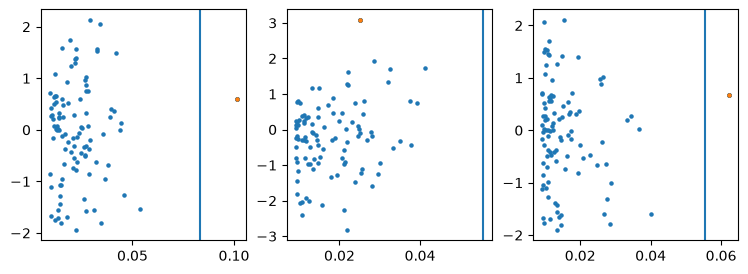

In [36]:
refit_resid = refit_model.resid
refit_resid_1 = refit_model_1.resid
refit_resid_2 = refit_model_2.resid

refit_leverage = refit_model.get_influence().hat_matrix_diag
refit_leverage_1 = refit_model_1.get_influence().hat_matrix_diag
refit_leverage_2 = refit_model_2.get_influence().hat_matrix_diag

refit_mean = np.mean(refit_leverage)
refit_mean_1 = np.mean(refit_leverage_1)
refit_mean_2 = np.mean(refit_leverage_2)

diagnostic = plt.Figure(figsize=(9,3))
axs = diagnostic.subplots(nrows=1, ncols=3)
axs[0].scatter(refit_leverage[:-1], refit_resid[:-1], s=5)
axs[0].scatter(refit_leverage[-1:], refit_resid[-1:], s=5)
axs[0].axvline(3*refit_mean)
axs[1].scatter(refit_leverage_1[:-1], refit_resid_1[:-1], s=5)
axs[1].scatter(refit_leverage_1[-1:], refit_resid_1[-1:], s=5)
axs[1].axvline(3*refit_mean_1)
axs[2].scatter(refit_leverage_2[:-1], refit_resid_2[:-1], s=5)
axs[2].scatter(refit_leverage_2[-1:], refit_resid_2[-1:], s=5)
axs[2].axvline(3*refit_mean_2)

diagnostic

The additional observation is
* a leverage point for the multiple linear regression model
* an outlier point for the simple linear regression model of `y` on `x1`
* a leverage point for the simple linear regression model of `y` on `x2`